## Modeling Dataset Construction

This notebook builds and evaluates predictive models for response-time estimation.

### Objectives
- Construct a leakage-aware feature set
- Use time-based train/validation/test splits
- Benchmark CatBoost against simple baselines
- Improve generalization through feature design and tuning


In [13]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, datetime as dt, numpy as np, glob, os
import sys
!{sys.executable} -m pip install pyarrow

pd.set_option('display.max_columns', None)

DRIVE_URL = "https://drive.google.com/uc?export=download&id=1F06NYKBF8loCTPEaPT_qIhcQy2T5iM6H"
DATA_PATH = "data.csv"

# Preferred: local multi-file raw data. Fallback: single downloaded CSV.
all_files = sorted(glob.glob("csv_files/get_it_done_requests_closed_20*_datasd.csv"))

if all_files:
    print(f"Loading {len(all_files)} local annual CSV files from csv_files/...")
    df_list = []
    for file in all_files:
        year = file.split('_')[-2]
        df = pd.read_csv(file)
        if 'year' not in df.columns:
            df['year'] = year
        df_list.append(df)
        print(f"Loaded {year}: {len(df)} rows")
    all_data = pd.concat(df_list, ignore_index=True)
else:
    if not os.path.exists(DATA_PATH):
        print("No local annual CSV files found. Attempting Google Drive download...")
        try:
            import gdown
            gdown.download(DRIVE_URL, DATA_PATH, quiet=False)
        except Exception as e:
            raise RuntimeError(
                "Could not load local CSVs and automatic download failed. "
                "Install gdown (`pip install gdown`) or place data.csv in project root."
            ) from e

    all_data = pd.read_csv(DATA_PATH, low_memory=False)
    if 'year' not in all_data.columns and 'date_requested' in all_data.columns:
        all_data['date_requested'] = pd.to_datetime(all_data['date_requested'], errors='coerce')
        all_data['year'] = all_data['date_requested'].dt.year
    print(f"Loaded single-file dataset: {len(all_data):,} rows")

# Data Cleaning
master = all_data[all_data["status"] != "Referred"].drop(columns=["referred"])
# Clean neighborhood names
master["comm_plan_name"] = master["comm_plan_name"].str.title()
def clean_case_type(case):
    if not isinstance(case,str):
        return case

    if "graffiti" in case.lower():
        return "Graffiti"
    return case

#Drop rows where service_name == "Other"(vague)
before_rows = len(master)
master = master[master["service_name"] != "Other"]
print(f"✓ Dropped 'Other' service type: {before_rows - len(master):,} rows")
#Remove invalid case_age_days (negative values)
before_rows = len(master)
master = master[master["case_age_days"] >= 0]
print(f"✓ Removed invalid case_age_days: {before_rows - len(master):,} rows")

#Remove duplicates (same service_request_id)
before_rows = len(master)
master = master[~master['service_request_id'].duplicated()]
print(f"✓ Removed duplicates: {before_rows - len(master):,} rows")

# keep consistent case types
master["service_name"] = master["service_name"].apply(clean_case_type)




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


/var/folders/xg/pjqjkzbx1lz9fgmz_njxvl6w0000gn/T/ipykernel_82277/3722643547.py:11: DtypeWarning: Columns (7,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Loaded 2016: 33631 rows
Loaded 2017: 139500 rows


/var/folders/xg/pjqjkzbx1lz9fgmz_njxvl6w0000gn/T/ipykernel_82277/3722643547.py:11: DtypeWarning: Columns (2,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Loaded 2018: 169603 rows


...

Loaded 2019: 302699 rows


/var/folders/xg/pjqjkzbx1lz9fgmz_njxvl6w0000gn/T/ipykernel_82277/3722643547.py:11: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Loaded 2020: 280071 rows


/var/folders/xg/pjqjkzbx1lz9fgmz_njxvl6w0000gn/T/ipykernel_82277/3722643547.py:11: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Loaded 2021: 359879 rows
Loaded 2022: 349241 rows
Loaded 2023: 432431 rows
Loaded 2024: 429933 rows
Loaded 2025: 378618 rows
✓ Dropped 'Other' service type: 26,693 rows
✓ Dropped negative response times: 670 rows
✓ Dropped duplicate IDs: 17 rows
Dropped 692 rows due to NA values
✓ Filled 32,519 missing neighborhoods with 'Unknown'
✓ Filled 479 missing case_origins with 'Unknown'


## Feature Engineering (Initial)

This section creates baseline temporal, text, and request-context features for first-pass modeling.


In [14]:
# Adding Features for modeling

model_data = master.copy()
#handles outliers
model_data = model_data[model_data["case_age_days"]<= 365*2]
# Continue with model_data (already filtered for outliers)
# Continue with model_data (already filtered for outliers)
print("\n=== FEATURE ENGINEERING ON MODEL_DATA ===")
print(f"Starting with {len(model_data):,} rows (after outlier removal)")

# Parse dates
model_data['date_requested'] = pd.to_datetime(model_data['date_requested'], errors='coerce')

# Temporal features
model_data['year'] = model_data['date_requested'].dt.year
model_data['month'] = model_data['date_requested'].dt.month
model_data['day_of_week'] = model_data['date_requested'].dt.dayofweek
model_data['hour'] = model_data['date_requested'].dt.hour
model_data['quarter'] = model_data['date_requested'].dt.quarter
model_data['is_weekend'] = (model_data['day_of_week'] >= 5).astype(int)

# Location features
model_data['is_district_56'] = model_data['council_district'].isin([5, 6]).astype(int)

# Fill missing council_district with 0 (Unknown)
missing_district = model_data['council_district'].isna().sum()
model_data['council_district'] = model_data['council_district'].fillna(0)
print(f"✓ Filled {missing_district:,} missing council_districts with 0 (Unknown)")

# Request type features
infrastructure_types = [
    'Pothole',
    'Street Light Maintenance',
    'Traffic Signal Issue',
    'Traffic Signal Timing',
    'Traffic Sign Maintenance',
    'Sidewalk Repair Issue',
    'Pavement Maintenance',
    'Street Repair',
    'Curb Repair'
]
model_data['is_infrastructure'] = model_data['service_name'].isin(infrastructure_types).astype(int)
model_data['is_followup'] = model_data['service_request_parent_id'].notna().astype(int)

# Text features
model_data['description_length'] = model_data['public_description'].str.len().fillna(0)
model_data['has_description'] = (model_data['description_length'] > 0).astype(int)

# Log-transformed target for regression
model_data['log_wait'] = np.log1p(model_data['case_age_days'])

# Target variable for classification
model_data['response_category'] = pd.cut(
    model_data['case_age_days'],
    bins=[0, 3, 7, 21, 90,730],
    labels=['very_fast', 'fast', 'medium', 'slow',"super_slow"],
    include_lowest=True
)

print("✓ Created all features")
# Dropping columns
columns_to_drop = [
    'date_closed',  # Already have case_age_days
    'service_request_id',  # Just an ID
    'service_request_parent_id',  # Used for is_followup feature
    'public_description',  # Used for description_length
    'sap_notification_number',  # Internal ID
    'specify_the_issue',  # Too many missing
    'public_url',  # Not useful for prediction
    'iamfloc',  # Internal code
    'floc',  # Internal code
    'park_name',  # Too many missing
]
model_data = model_data.drop(columns=columns_to_drop)

model_data['has_service_name_detail'] = model_data['service_name_detail'].notna().astype(int)
print(f"✓ Dropped {len(columns_to_drop)} unnecessary columns")

# Summary
print("\n=== MODEL DATA SUMMARY ===")
print(f"Total rows: {len(model_data):,}")
print(f"Total columns: {len(model_data.columns)}")

print(f"\nTarget variable (case_age_days) statistics:")
print(model_data['case_age_days'].describe())

print(f"\nResponse category distribution:")
print(model_data['response_category'].value_counts())

print(f"\nKey features created:")
print(f"  - Temporal: year, month, day_of_week, hour, quarter, is_weekend")
print(f"  - Location: is_district_56, council_district (0 = Unknown)")
print(f"  - Request type: is_infrastructure, is_followup")
print(f"  - Text: description_length, has_description")
print(f"  - Target: response_category (very_fast/fast/medium/slow)")

# Check for any remaining missing values in key columns
print("\n=== MISSING VALUES CHECK ===")
key_cols = ['service_name', 'council_district', 'case_age_days', 'year', 'month', 'day_of_week']
missing_summary = model_data[key_cols].isna().sum()
print(missing_summary[missing_summary > 0] if missing_summary.sum() > 0 else "No missing values in key columns ✓")

print(f"\n✓ 'model_data' ready with {len(model_data):,} rows and {len(model_data.columns)} columns")
print(f"✓ Original 'master' dataframe preserved for EDA")



=== FEATURE ENGINEERING ON MODEL_DATA ===
Starting with 2,452,953 rows (after outlier removal)
✓ Filled 32,059 missing council_districts with 0 (Unknown)
✓ Created all features
✓ Dropped 10 unnecessary columns

=== MODEL DATA SUMMARY ===
Total rows: 2,452,953
Total columns: 28

Target variable (case_age_days) statistics:
count    2.452953e+06
mean     3.293461e+01
std      8.359300e+01
min      0.000000e+00
25%      1.000000e+00
50%      5.000000e+00
75%      2.200000e+01
max      7.300000e+02
Name: case_age_days, dtype: float64

Response category distribution:
response_category
very_fast     1067713
medium         423587
slow           399553
fast           339958
super_slow     222142
Name: count, dtype: int64

Key features created:
  - Temporal: year, month, day_of_week, hour, quarter, is_weekend
  - Location: is_district_56, council_district (0 = Unknown)
  - Request type: is_infrastructure, is_followup
  - Text: description_length, has_description
  - Target: response_category (v

## Feature Engineering (Refinement Iterations)

This section adds and tests stronger features after baseline evaluation, including cleaned categorical fields and interaction/context features.


In [15]:
import numpy as np
import re

model_data = model_data.copy()

def norm_text(x):
    x = str(x)
    x = x.strip().lower()
    x = re.sub(r"\s+", " ", x)   # collapse repeated spaces
    return x

# Raw strings
s_raw = model_data["service_name"].fillna("Missing").astype(str)
d_raw = model_data["service_name_detail"].fillna("Missing").astype(str)

# Normalized strings for matching only
s_norm = s_raw.map(norm_text)
d_norm = d_raw.map(norm_text)

# Same-as-service flag using normalized text
same_mask = d_norm == s_norm

# Build cleaned detail
model_data["service_name_detail_clean"] = np.where(
    same_mask,
    "SameAsService",
    d_raw
).astype(str)

# Rare bucket after same-as collapse
counts = model_data["service_name_detail_clean"].value_counts()
rare = counts[counts < 150].index
model_data["service_name_detail_clean"] = model_data["service_name_detail_clean"].replace(rare, "Other")

# Extra-detail indicator
model_data["has_extra_detail"] = (~same_mask).astype(int)

print(model_data["service_name_detail_clean"].value_counts().head(20))



service_name_detail_clean
Missing                                   851279
SameAsService                             649392
72 Hour Violation                         286225
Graffiti Removal                          118054
Parking Zone Violation                     49997
STREET LIGHT OUT                           46364
Potential Missed Collection                31723
LIGHTS OUT                                 22466
Other                                      22413
Container Left Out                         20556
CONCRETE SIDEWALK REPAIR ISSUE             20082
LIGHTS ON FLASH                            16853
SWPP - Storm Water Polution Prevention     14604
Red Zone                                   14586
Graffiti Removal - Commercial              13085
DRAIN INLET                                11635
EVALUATE TREE FOR REMOVAL                   9118
Sidewalk                                    9078
Commercial Property                         8903
Graffiti                                   

In [16]:
model_data = model_data.copy()

# 1) Prep
model_data["date_requested"] = pd.to_datetime(model_data["date_requested"], errors="coerce")
model_data = model_data.dropna(subset=["date_requested"]).sort_values("date_requested").reset_index(drop=True)

model_data["service_name"] = model_data["service_name"].fillna("Missing").astype(str)
model_data["comm_plan_name"] = model_data["comm_plan_name"].fillna("Missing").astype(str)

# helper for rolling counts
model_data["_one"] = 1.0

# 2) 30-day workload features (leakage-safe: prior window only)
# Build each rolling feature within group and return values aligned to original row index.
model_data["workload_30d_service"] = (
    model_data.groupby("service_name", group_keys=False)
    .apply(
        lambda g: pd.Series(
            g.set_index("date_requested")["_one"].rolling("30D", closed="left").sum().to_numpy(),
            index=g.index,
        )
    )
    .fillna(0)
)

model_data["workload_30d_neighborhood"] = (
    model_data.groupby("comm_plan_name", group_keys=False)
    .apply(
        lambda g: pd.Series(
            g.set_index("date_requested")["_one"].rolling("30D", closed="left").sum().to_numpy(),
            index=g.index,
        )
    )
    .fillna(0)
)

model_data["workload_30d_service_neighborhood"] = (
    model_data.groupby(["service_name", "comm_plan_name"], group_keys=False)
    .apply(
        lambda g: pd.Series(
            g.set_index("date_requested")["_one"].rolling("30D", closed="left").sum().to_numpy(),
            index=g.index,
        )
    )
    .fillna(0)
)

# 3) Interaction feature
model_data["service_x_neighborhood"] = (
    model_data["service_name"] + " | " + model_data["comm_plan_name"]
)

# optional: collapse rare interaction categories
vc = model_data["service_x_neighborhood"].value_counts()
rare = vc[vc < 100].index
model_data["service_x_neighborhood"] = model_data["service_x_neighborhood"].replace(rare, "Other")

# cleanup
model_data = model_data.drop(columns=["_one"])



/var/folders/xg/pjqjkzbx1lz9fgmz_njxvl6w0000gn/T/ipykernel_82277/236868000.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
/var/folders/xg/pjqjkzbx1lz9fgmz_njxvl6w0000gn/T/ipykernel_82277/236868000.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
/var/folders/xg/pjqjkzbx1lz9fgmz_njxvl6w0000gn/T/ipykernel_82277/236868000.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping col

## Quick Correlation Screening using Heatmap

This section provides a quick directional check of numerical associations with `log_wait`.

It is used for feature intuition only; final model decisions are based on validation/test performance.


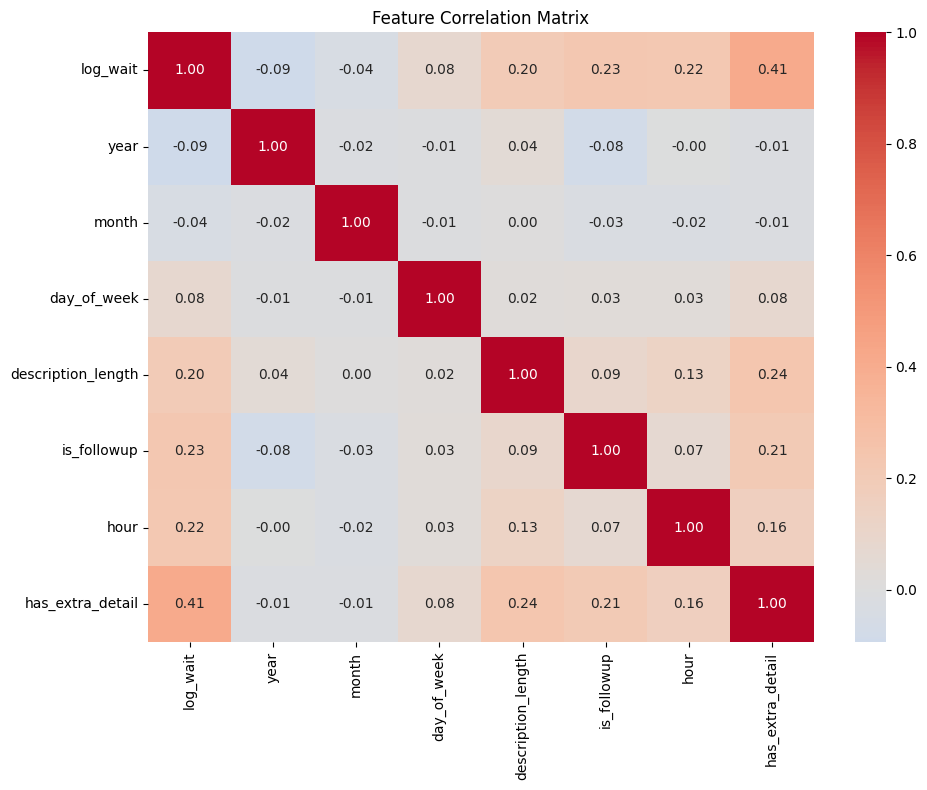


=== CORRELATION WITH RESPONSE TIME ===
log_wait              1.000000
has_extra_detail      0.414107
is_followup           0.229216
hour                  0.221147
description_length    0.202284
day_of_week           0.077306
month                -0.042732
year                 -0.093801
Name: log_wait, dtype: float64


In [17]:
# Create potential features first
#model_data = model_data[(model_data["year"]=="2024") | (model_data["year"]=="2025")]
# Correlation matrix for numerical features
cat_df = model_data[model_data["year"] >= 2023]
numerical_features = ['log_wait', 'year', 'month', 
                      'day_of_week', "description_length","is_followup",'hour', 'has_extra_detail']

corr_data = cat_df[numerical_features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Print correlations with target
print("\n=== CORRELATION WITH RESPONSE TIME ===")
print(corr_data['log_wait'].sort_values(ascending=False))

## CatBoost Modeling

CatBoost is used to handle mixed numerical/categorical tabular data with minimal manual encoding and strong baseline performance on operational datasets.


## Validation Strategy

A strict time-based split is used to mimic deployment conditions and avoid future-to-past leakage:
- Train: earlier period
- Validation: intermediate period
- Test: most recent period


## Train/Validation/Test Feature Assembly

This section defines numeric/categorical feature lists, applies consistent categorical preprocessing, and builds model matrices for each split.


In [18]:

x_numerical = ['year', 'month', 'description_length', 'hour', 'is_followup','day_of_week', "workload_30d_service", "workload_30d_neighborhood", "workload_30d_service_neighborhood"]
x_cat = ['service_name', 'council_district', 'comm_plan_name', 'case_origin', 'service_name_detail_clean', 'case_record_type', "service_x_neighborhood"]
x_numerical.sort()
x_cat.sort()
y = 'log_wait'
x_total = x_numerical + x_cat
cat_df = cat_df.copy()
for c in x_cat:
    cat_df[c] = cat_df[c].fillna('Missing').astype(str)

train_df = cat_df[cat_df['date_requested'] < '2025-01-01'].copy()
valid_df = cat_df[(cat_df['date_requested'] >= '2025-01-01') & (cat_df['date_requested'] < '2025-07-01')].copy()
test_df = cat_df[cat_df['date_requested'] >= '2025-07-01'].copy()

print(f'train_df shape is {train_df.shape} | {len(train_df)/len(cat_df)*100}%')
print(f'valid_df shape is {valid_df.shape} | {len(valid_df)/len(cat_df)*100}%')
print(f'test_df shape is {test_df.shape} | {len(test_df)/len(cat_df)*100}%')

X_train = train_df[x_total]
X_valid = valid_df[x_total]
X_test = test_df[x_total]

y_train = train_df[y]
y_valid = valid_df[y]
y_test = test_df[y]

train_df shape is (764947, 34) | 70.42692723059373%
valid_df shape is (163790, 34) | 15.079772077149068%
test_df shape is (157420, 34) | 14.493300692257197%


## Median Baseline

A naive median predictor is used as a reference point to verify that the model provides meaningful lift over a simple baseline.


In [19]:
train_median = train_df['case_age_days'].median()
prediction_median = np.full(len(y_test), train_median)

median_r2_days = r2_score(true_days, prediction_median)
median_rmse_days = np.sqrt(mean_squared_error(true_days, prediction_median))
median_mae_days = mean_absolute_error(true_days, prediction_median)

print(f"R^2 in Days is {np.round(median_r2_days, 3)}")
print(f"RSME in Days is {np.round(median_rmse_days, 3)}")
print(f"MAE in Days is {np.round(median_mae_days, 3)} days")

R^2 in Days is -0.091
RSME in Days is 20.77
MAE in Days is 9.71 days


In [20]:
from catboost import CatBoostRegressor
cat_boost = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=1000,

    learning_rate=0.05,
    depth=6,
    random_seed = 42,
    od_type = 'Iter',
    od_wait = 50,
    verbose = 100,
    
)

cat_model = cat_boost.fit(X_train, y_train, cat_features=x_cat, eval_set=(X_valid, y_valid), use_best_model=True)

results_log = cat_model.predict(X_test)



0:	learn: 1.5504559	test: 1.4708491	best: 1.4708491 (0)	total: 111ms	remaining: 1m 50s
100:	learn: 1.0002227	test: 1.0518410	best: 1.0504737 (92)	total: 5.81s	remaining: 51.7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1.048654857
bestIteration = 138

Shrink model to first 139 iterations.


## Baseline CatBoost Results

This section reports baseline CatBoost performance before extensive tuning and feature expansion.


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

evals = cat_model.get_evals_result()
print(evals.keys())
print(evals['validation']['RMSE'][-5:])

true_log = y_test.values

pred_days = np.expm1(results_log)
true_days = np.expm1(true_log)
## Day results

r2_days = r2_score(true_days, pred_days)
rmse_days = np.sqrt(mean_squared_error(true_days, pred_days))
mae_days = mean_absolute_error(true_days, pred_days)

##log results
r2_log = r2_score(true_log, results_log)
rmse_log = np.sqrt(mean_squared_error(true_log, results_log))
mae_log = mean_absolute_error(true_log, results_log)

print(f"R^2 in Days is {np.round(r2_days, 3)}")
print(f"RSME in Days is {np.round(rmse_days, 3)}")
print(f"MAE in Days is {np.round(mae_days, 3)} days")
print()
print(f"R^2 Logged is {np.round(r2_log, 3)}")
print(f"RSME Logged is {np.round(rmse_log, 3)}")
print(f"MAE Logged is {np.round(mae_log, 3)}")

# returns a list of important features aligned to the training feature order
# so we will put it in a dataframe with it to see the ranking
feature_importance = cat_model.get_feature_importance()

feature_ranking = pd.DataFrame({"Feature":X_train.columns, "Importance":feature_importance}).sort_values('Importance', ascending=False)
feature_ranking


dict_keys(['learn', 'validation'])
[1.049558350327692, 1.0495630650511691, 1.0496334521407673, 1.0494994054591988, 1.0499466338363819]
R^2 in Days is 0.208
RSME in Days is 17.69
MAE in Days is 8.371 days

R^2 Logged is 0.459
RSME Logged is 0.967
MAE Logged is 0.688


,Feature,Importance
14,service_name_detail_clean,25.654555
9,case_origin,24.445388
13,service_name,18.514292
10,case_record_type,11.800339
4,month,3.647909
15,service_x_neighborhood,3.647648
6,workload_30d_service,3.286318
8,year,2.815320
3,is_followup,2.615595
2,hour,1.254409


## Hyperparameter Optimization (Optuna)

This section tunes CatBoost hyperparameters on the validation split while preserving the fixed time-based test set for final evaluation.


In [22]:
import optuna
import json
from pathlib import Path
# objective does the training and you are returning the parameter that you want to be optimized
def objective(trial):
    params = {
        "loss_function":"RMSE",
        "eval_metric":'RMSE',
        
        "iterations": trial.suggest_int('iterations', 500, 4000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 3,10),
        
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 100.0, log=True),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 20, 1000),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "random_strength": trial.suggest_float("random_strength", 1e-3, 10.0, log=True),

        'random_seed': 42,
        'od_type': 'Iter',
        'od_wait' :50,
        'verbose':False
        
    }
    optuna_model = CatBoostRegressor(**params)

    optuna_model.fit(X_train, y_train, cat_features=x_cat, eval_set=(X_valid, y_valid), use_best_model=True)

    optuna_pred_valid = optuna_model.predict(X_valid)
    rmse_valid = np.sqrt(mean_squared_error(y_valid, optuna_pred_valid))
    return rmse_valid # want to minimize this

study = optuna.create_study(direction='minimize', study_name="cat_boost_logwait_tune")
study.optimize(objective, n_trials=15, show_progress_bar=True)

print('Best value(RMSE Log) is: ', study.best_value)
print('Best Params:')
for key, value in study.best_params.items():
    print(f"{key}: {value}")

out = {
    "best_value": study.best_value,
    "best_params": study.best_params,
    "direction": study.direction.name,
    "n_trials": len(study.trials),
}

Path("models").mkdir(exist_ok=True)
with open("models/optuna_best_params.json", "w") as f:
    json.dump(out, f, indent=2)

print("Saved to models/optuna_best_params.json")


[I 2026-03-24 16:21:14,729] A new study created in memory with name: cat_boost_logwait_tune
Best trial: 0. Best value: 1.05603:   7%|▋         | 1/15 [00:06<01:28,  6.33s/it]

[I 2026-03-24 16:21:21,058] Trial 0 finished with value: 1.0560300677250647 and parameters: {'iterations': 1904, 'learning_rate': 0.05797256608603932, 'depth': 4, 'l2_leaf_reg': 3.29421424158078, 'min_data_in_leaf': 622, 'subsample': 0.7647230733953818, 'random_strength': 0.0016303974100616053}. Best is trial 0 with value: 1.0560300677250647.


Best trial: 0. Best value: 1.05603:  13%|█▎        | 2/15 [00:23<02:48, 12.93s/it]

[I 2026-03-24 16:21:38,611] Trial 1 finished with value: 1.0567575077922349 and parameters: {'iterations': 1678, 'learning_rate': 0.012766128298795872, 'depth': 4, 'l2_leaf_reg': 8.143106339299266, 'min_data_in_leaf': 440, 'subsample': 0.8440459938015322, 'random_strength': 1.1983177239885963}. Best is trial 0 with value: 1.0560300677250647.


Best trial: 2. Best value: 1.05581:  20%|██        | 3/15 [00:30<02:00, 10.03s/it]

...

[I 2026-03-24 16:24:16,785] Trial 12 finished with value: 1.0410952374575617 and parameters: {'iterations': 569, 'learning_rate': 0.0532289640102591, 'depth': 9, 'l2_leaf_reg': 16.15930305457886, 'min_data_in_leaf': 62, 'subsample': 0.6691389984386878, 'random_strength': 8.769050733541864}. Best is trial 8 with value: 1.039448178776324.


Best trial: 8. Best value: 1.03945:  93%|█████████▎| 14/15 [03:11<00:13, 13.34s/it]

[I 2026-03-24 16:24:25,902] Trial 13 finished with value: 1.0430670199717966 and parameters: {'iterations': 2365, 'learning_rate': 0.05643471913930481, 'depth': 8, 'l2_leaf_reg': 9.967471543209117, 'min_data_in_leaf': 253, 'subsample': 0.6950186367565947, 'random_strength': 2.2335898438515582}. Best is trial 8 with value: 1.039448178776324.


Best trial: 8. Best value: 1.03945: 100%|██████████| 15/15 [03:34<00:00, 14.27s/it]

[I 2026-03-24 16:24:48,730] Trial 14 finished with value: 1.0420954917739575 and parameters: {'iterations': 715, 'learning_rate': 0.024002793550709996, 'depth': 9, 'l2_leaf_reg': 32.25824843410318, 'min_data_in_leaf': 276, 'subsample': 0.9202545206966564, 'random_strength': 8.78664642630929}. Best is trial 8 with value: 1.039448178776324.
Best value(RMSE Log) is:  1.039448178776324
Best Params:
iterations: 2683
learning_rate: 0.012026068919134016
depth: 10
l2_leaf_reg: 26.01549806800122
min_data_in_leaf: 412
subsample: 0.7723299903439417
random_strength: 1.3487693201420443
Saved to models/optuna_best_params.json


## Optimized Model Results and Tradeoffs

Optimization improves performance, but feature quality and leakage-safe context features are the primary drivers of larger gains in this project.


## Stronger Feature Development

### Changes Introduced
- Cleaned `service_name_detail` categories
- Added service-context fields (for example, `case_record_type`)
- Added interaction/context features and rolling workload signals

### Challenges Encountered
- Categorical type errors (float/NaN in `cat_features`)
- Rolling-window index alignment issues in pandas
- Run-to-run variance caused by non-deterministic row ordering and threading

### Resolutions
- Enforced string casting and explicit missing tokens for categorical features
- Rebuilt rolling features with index-safe alignment
- Applied deterministic sorting before feature generation and split construction

### Current Documented Outcome
Feature engineering delivered the largest gains relative to baseline and reduced test error meaningfully.


In [23]:
best_params = {
    **study.best_params,
    'random_seed':42,
    'eval_metric': 'RMSE',
    'loss_function':'RMSE',
    'od_type':'Iter',
    'od_wait':100,
    "verbose":100
}


best_cat_model = CatBoostRegressor(**best_params)
best_cat_model.fit(X_train, y_train, cat_features=x_cat, eval_set=(X_valid, y_valid), use_best_model=True)

true_log_opt = y_test.values
true_days_opt = np.expm1(true_log_opt)

best_pred_log = best_cat_model.predict(X_test)
best_pred_days = np.expm1(best_pred_log)


best_r2_days = r2_score(true_days_opt, best_pred_days)
best_rmse_days = np.sqrt(mean_squared_error(true_days_opt, best_pred_days))
best_mae_days = mean_absolute_error(true_days_opt, best_pred_days)

##log results
best_r2_log = r2_score(true_log_opt, best_pred_log)
best_rmse_log = np.sqrt(mean_squared_error(true_log_opt, best_pred_log))
best_mae_log = mean_absolute_error(true_log_opt, best_pred_log)

print(f"R^2 in Days is {np.round(best_r2_days, 3)}")
print(f"RSME in Days is {np.round(best_rmse_days, 3)}")
print(f"MAE in Days is {np.round(best_mae_days, 3)} days")
print()
print(f"R^2 Logged is {np.round(best_r2_log, 3)}")
print(f"RSME Logged is {np.round(best_rmse_log, 3)}")
print(f"MAE Logged is {np.round(best_mae_log, 3)}")

best_feature_importance = best_cat_model.get_feature_importance()

best_feature_ranking = pd.DataFrame({"Feature":X_train.columns, "Importance":best_feature_importance}).sort_values('Importance', ascending=False)
best_feature_ranking

0:	learn: 1.5817702	test: 1.5023619	best: 1.5023619 (0)	total: 109ms	remaining: 4m 51s
100:	learn: 1.0814668	test: 1.0774885	best: 1.0774885 (100)	total: 10.9s	remaining: 4m 39s
200:	learn: 0.9998351	test: 1.0409068	best: 1.0409068 (200)	total: 23.6s	remaining: 4m 51s
300:	learn: 0.9764448	test: 1.0399660	best: 1.0394482 (244)	total: 37.6s	remaining: 4m 57s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1.03944818
bestIteration = 244

Shrink model to first 245 iterations.
R^2 in Days is 0.258
RSME in Days is 17.127
MAE in Days is 8.001 days

R^2 Logged is 0.485
RSME Logged is 0.944
MAE Logged is 0.698


,Feature,Importance
9,case_origin,24.331742
14,service_name_detail_clean,23.143449
13,service_name,16.109181
10,case_record_type,12.666442
8,year,5.317656
4,month,5.272863
6,workload_30d_service,4.477354
3,is_followup,2.932157
15,service_x_neighborhood,2.225803
2,hour,1.048655


## Notebook Summary

CatBoost outperforms naive baseline prediction on the held-out time split.
Most performance gains came from improved feature design and leakage-aware preprocessing, with tuning providing incremental gains.
